# 📊 **Unsuperviced Learning. Clustering Analysis using K-means** 📚

### 🗂️ **Strategic Customer Segmentation via RFM Analysis**
---

In **Business Intelligence** and Analytics pipelines, unsupervised learning serves as the primary mechanism to discover hidden behavioral archetypes within a customer base without relying on manual labeling. While advanced transactional architectures record millions of row-level event logs, modeling clustering algorithms directly onto raw time-series data is computationally inefficient and lacks direct business interpretability.

To bridge the gap between engineering features and strategic decision-making, we compress transactional histories into an RFM (Recency, Frequency, Monetary) Model. This framework extracts three fundamental spatial dimensions for each unique identifier:

* ⏰ **Recency** ($R$): The number of days elapsed since the customer's last transactional event. A lower value indicates high immediate engagement, while high values suggest potential attrition or complete churn.

* 📅 **Frequency** ($F$): The total count of distinct purchase sessions within a defined historical window. This captures long-term habituation, brand loyalty, and behavioral velocity.

* 💰 **Monetary** ($M$): The total financial volume or aggregate net revenue generated by the entity over the same time window. This measures financial equity and customer lifetime value (CLV) scaling.

### 🎯 **Core Notebook Objectives and Feature Standardization**
---

📌 **STEP 1:** We will transform our **RFM variables** to normalize their distributions, preventing mathematical fluctuations and bias in distance calculations caused by the massive scale differences between days, counts, and currency values.

📌 **STEP 2:** The following is establish our baseline model, iterate across multiple cluster counts ($k$), and analyze the mathematical trade-offs using the **Elbow Method and Silhouette Analysis** to choose our optimal segment count.

📌 **STEP 3:** Once the optimal centroids are computed, we will **map to profile our customer groups** (VIPs, At-Risk, New, and Loyal Core) and assign actionable business strategies to each group.

---

## 📖 **1. Reading and exploring data**
---

In [14]:
#Basic Python imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#KMeans + PCA tools
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [15]:
#READING DATA
route = "https://raw.githubusercontent.com/hector1994/churn_model_v1/refs/heads/master/online_retail_rfm_20k.csv"
df    = pd.read_csv(route)

In [16]:
#VISUALIZE DATA
df.head()

,CustomerID,Recency,Frequency,Monetary
0,ID_110650,201,2,241483.0
1,ID_102041,4,26,875895.0
2,ID_108668,192,4,397337.0
3,ID_101114,4,41,1034240.0
4,ID_113902,182,6,291823.0


In [17]:
#BASIC EXPLORATION
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  20000 non-null  object 
 1   Recency     20000 non-null  int64  
 2   Frequency   20000 non-null  int64  
 3   Monetary    20000 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 625.1+ KB


None

,Recency,Frequency,Monetary
count,20000.00000,20000.000000,2.000000e+04
mean,69.96745,13.063650,4.006281e+05
std,69.58537,12.375704,3.051154e+05
min,1.00000,1.000000,1.373700e+04
25%,7.00000,4.000000,1.164940e+05
50%,45.00000,7.000000,3.330300e+05
75%,142.25000,19.000000,5.563232e+05
max,264.00000,58.000000,1.300851e+06


### **Put your initial comments here** 👇

## 📋 **2. Data preparation**
---

In [18]:
#EXTRACTING FEATURES
X_features = df[["Recency", "Frequency", "Monetary"]]

#SCALING FEATURES
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

In [19]:
#CHECKING SCALED FEATURES (-3 <= Z <= 3)
X_scaled

array([[ 1.88309448, -0.8940038 , -0.52160311],
       [-0.94803117,  1.04532826,  1.5577017 ],
       [ 1.75375372, -0.73239279, -0.01078684],
       ...,
       [-0.93365997, -0.73239279, -1.17190453],
       [-0.91928877,  1.53016127,  1.34836581],
       [-0.38755451, -0.08594877,  0.72627082]])

##🏋️‍♂️ **3. Model training - Hyperparameter tuning** ($k$)
---

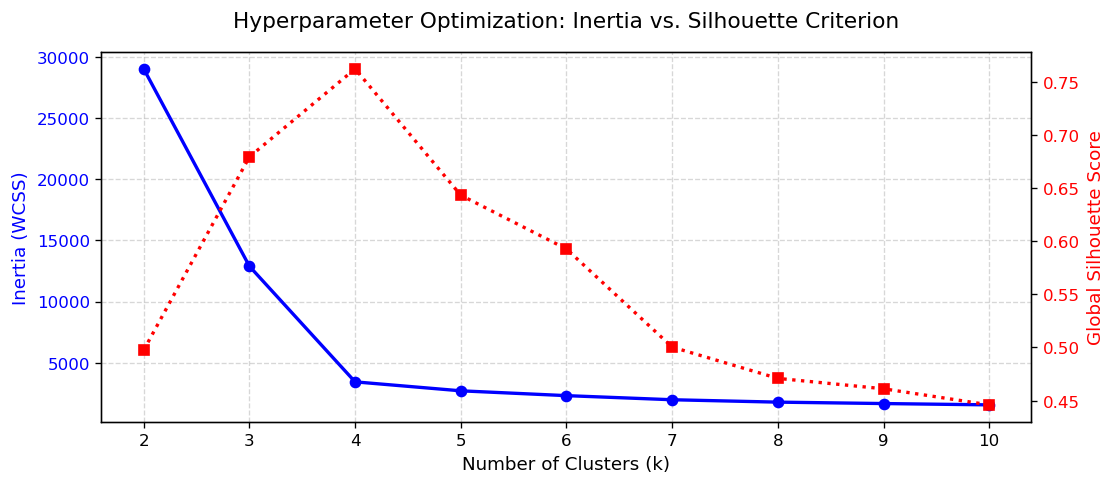

In [20]:
# MODEL ITERATIVE TRAINING

inertia_hist      = []
silhouette_hist   = []
k_range           = range(2, 11)

# ITERATIVE LOOP OVER THE K-RANGE TO EVALUATE GEOMETRIC METRICS
for k in k_range:
    kmeans_eval = KMeans(
        n_clusters=k, init="k-means++", random_state=42, n_init=10
    )
    labels_eval = kmeans_eval.fit_predict(X_scaled)

    # WITHIN-CLUSTER SUM OF SQUARES (INERTIA)
    inertia_hist.append(kmeans_eval.inertia_)
    # GLOBAL SILHOUETTE COEFFICIENT
    silhouette_hist.append(silhouette_score(X_scaled, labels_eval))

# DUAL VISUALIZATION OF MATHEMATICAL DIAGNOSTIC CURVES
fig, ax1 = plt.subplots(figsize=(10, 4), dpi=120)

color = "blue"
ax1.set_xlabel("Number of Clusters (k)", fontsize=11)
ax1.set_ylabel("Inertia (WCSS)", color=color, fontsize=11)
ax1.plot(k_range, inertia_hist, marker="o", color=color, linewidth=2)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
color = "red"
ax2.set_ylabel("Global Silhouette Score", color=color, fontsize=11)
ax2.plot(
    k_range,
    silhouette_hist,
    marker="s",
    color=color,
    linewidth=2,
    linestyle=":",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Hyperparameter Optimization: Inertia vs. Silhouette Criterion",
    fontsize=13,
    pad=15,
)
plt.show()

## 🚀 **Training model using optimal $k$ value**
---

In [21]:
#TRAINING OPTIMAL MODEL
k_opt = 4
final_kmeans = KMeans(
    n_clusters=k_opt, init="k-means++", random_state=42, n_init=10
)
df["Cluster"] = final_kmeans.fit_predict(X_scaled)

In [22]:
#PERFORMANCE METRICS
inercia_final = final_kmeans.inertia_
silueta_final = silhouette_score(X_scaled, df["Cluster"])

print("=== MÉTRICAS DE RENDIMIENTO DEL MODELO ===")
print(f"Inercia Final (WCSS Global): {inercia_final:,.2f}")
print(f"Coeficiente de Silueta Promedio Global: {silueta_final:.4f}\n")

=== MÉTRICAS DE RENDIMIENTO DEL MODELO ===
Inercia Final (WCSS Global): 3,430.45
Coeficiente de Silueta Promedio Global: 0.7622



In [23]:
df.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,ID_110650,201,2,241483.0,1
1,ID_102041,4,26,875895.0,0
2,ID_108668,192,4,397337.0,1
3,ID_101114,4,41,1034240.0,0
4,ID_113902,182,6,291823.0,1


In [24]:
# PROFILING AND CENTROID INTERPRETATION
print("CENTROID PROFILING AND INTERPRETATION - EACH CLUSTER FINAL CENTROID")

profile = df.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean() #AVERAGE ECACH FEATURE PER CLUSTER

profile["Customer_Volume"] = df.groupby("Cluster")["CustomerID"].count()     #FINAL CUSTOMERS IN THE k=0,1,2,3 CLUSTER AND ITS SHARE
profile["Customer_Pct"] = (
    (profile["Customer_Volume"] / len(df)) * 100
).round(2)
print(profile.round(2))
print("\n")

CENTROID PROFILING AND INTERPRETATION - EACH CLUSTER FINAL CENTROID
         Recency  Frequency   Monetary  Customer_Volume  Customer_Pct
Cluster                                                              
0           4.54      37.98  978761.54             3000         15.00
1         159.00       6.01  310200.52             6990         34.95
2           7.16       3.00   42119.91             5005         25.02
3          47.65      18.04  538894.42             5005         25.02




## 📊 **4. K-means + PCA - Visualizing in a reduced 2D space**
---

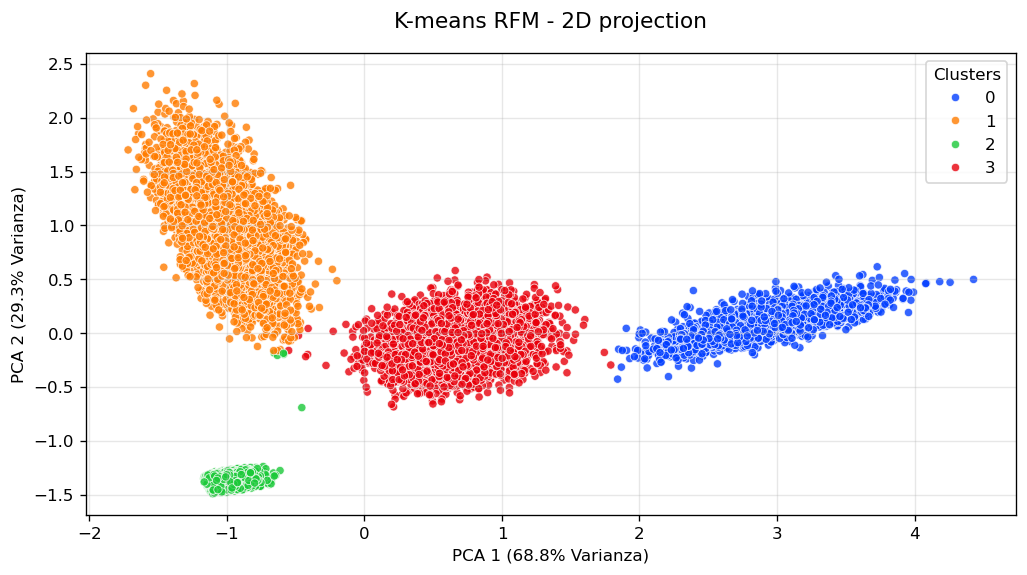

In [25]:
#APPLYING PCA TO VISUALIZE THE CLUSTERS IN A 2-D SPACE.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df["Cluster"]

plt.figure(figsize=(10, 5), dpi = 120)

# PCA - RFM plot
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="bright",
    alpha=0.8,
    edgecolor="w",
    linewidth=0.5,
    s=25,
)


plt.title(
    "K-means RFM - 2D projection",
    fontsize=13,
    pad=15,
)
plt.xlabel(
    f"PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianza)",
    fontsize=10,
)
plt.ylabel(
    f"PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianza)",
    fontsize=10,
)
plt.grid(True, alpha=0.3)
plt.legend(title="Clusters", loc="upper right")
plt.show()

In [26]:
#CHECKING THE Z1,Z2 Principal Components
df_pca.head()

,PC1,PC2,Cluster
0,-1.605547,1.427737,1
1,2.045791,-0.162711,0
2,-1.121836,1.519148,1
3,3.204631,0.179394,0
4,-1.183498,1.277765,1


## 💼 **5. Businnes analysis**
---

### **Strategic Business Takeaways**

* **Maximize VIP Retention (High Monetary, Low Recency, High Frequency):**

This segment represents the financial engine of the platform. Since they show intense purchase velocity and massive credit capacity, marketing budgets should pivot away from transactional discounts and focus entirely on exclusive loyalty pipelines, early-access features, and premium customer service.

* **Accelerate New User Activation (Low Monetary, Low Recency, Low Frequency):**

These are recently acquired users who are testing the platform but have low financial exposure. The strategic objective is to shorten their secondary purchase cycle using automated onboarding triggers, personalized welcome cross-sales, and first-time behavioral incentives to build immediate habituation.

* **Execute High-Priority Win-Back Pipelines (Med-High Monetary, High Recency, Low-Med Frequency):**

This group represents critical revenue leakage; these are historically high-value customers who have abandoned active engagement. Business intelligence systems must instantly trigger high-incentive reactive campaigns, feedback loops, or direct outreach before these accounts reach permanent churn.

* **Stabilize and Upgrade the Loyal Core (Moderate Monetary, Moderate Recency, Moderate Frequency):**

This cluster provides the steady, predictable baseline revenue for the company. Strategy here should focus on marginal value upgrades, such as introducing recurring subscription models, tier-up incentives, and steady engagement triggers—to systematically transition them into the VIP bracket.